# 04 — Fine Wine Heterogeneity Analysis

**Purpose**: Demonstrate that fine wine is highly heterogeneous — individual wines behave very
differently from each other and from market indices during downturns.

**Target wines** (LWIN7): Salon (1807626), DRC Echezeaux (1028658), Lafite (1011872)

**Data source**: `focal_wines_vwap_monthly.parquet` produced by `01_data_setup.ipynb`

## Sections
1. Environment setup
2. Load parquets & prepare series
3. Chart 1: VWAP price series (2005+)
4. Chart 2: GFC drawdown comparison (indexed to 100 at Jan 2007)
5. Chart 3: Monthly trade volume per wine
6. Chart 4: Stress period performance — grouped bar
7. Data quality assertions

## 1. Environment Setup

In [1]:
import sys
from pathlib import Path

# ---------------------------------------------------------------------------
# Ensure the repo root is in sys.path so project modules can be imported
# regardless of whether this notebook is opened from the repo root or the
# notebook directory itself.
# ---------------------------------------------------------------------------
def _find_repo_root(start: Path) -> Path:
    for parent in [start, *start.parents]:
        if (parent / 'pyproject.toml').exists() or (parent / '.git').exists():
            return parent
    raise RuntimeError(
        'Could not find repo root (no pyproject.toml or .git found). '
        f'Searched from: {start}'
    )

_repo_root = str(_find_repo_root(Path.cwd()))
if _repo_root not in sys.path:
    sys.path.insert(0, _repo_root)

print(f'Repo root: {_repo_root}')

Repo root: /home/runner/work/report-for-me/report-for-me


In [2]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import yfinance as yf
from pathlib import Path

warnings.filterwarnings("ignore")

plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white'})

# ---------------------------------------------------------------------------
# Paths — notebook lives in projects/correlation-diversification/notebooks/
# ---------------------------------------------------------------------------
NOTEBOOK_DIR = Path("__file__").resolve().parent
PROJECT_DIR  = NOTEBOOK_DIR.parent
DATA_DIR     = PROJECT_DIR / "data"
IMAGES_DIR   = PROJECT_DIR / "images" / "heterogeneity"
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

FOCAL_WINES_PARQUET = DATA_DIR / "focal_wines_vwap_monthly.parquet"
COMPARISON_PARQUET  = DATA_DIR / "comparison_assets_monthly.parquet"

# ---------------------------------------------------------------------------
# Constants
# ---------------------------------------------------------------------------
WINE_LABELS = {
    "1807626": "Salon",
    "1028658": "DRC Echezeaux",
    "1011872": "Lafite",
}

# WineFi brand colours
WINEFI_COLOURS = [
    '#9437ff',  # purple  — primary
    '#83D483',  # mantis
    '#FFD166',  # sunglow
    '#F78C6B',  # coral
    '#4D87D0',  # blue
    '#EF476F',  # red
    '#06D6A0',  # emerald
    '#C23FB7',  # pink/purple
    '#4A4A68',  # slate
]

WINE_COLORS = {
    "Salon":        WINEFI_COLOURS[0],  # purple
    "DRC Echezeaux":  WINEFI_COLOURS[4],  # blue
    "Lafite":       WINEFI_COLOURS[5],  # red
}
LIVEX_COLOR  = WINEFI_COLOURS[1]  # mantis
SP500_COLOR  = WINEFI_COLOURS[2]  # sunglow
STRESS_SHADE = WINEFI_COLOURS[8]  # slate

# Stress periods as per issue spec
STRESS_PERIODS = [
    ("2008-09-01", "2009-03-31", "GFC"),
    ("2020-02-01", "2020-04-30", "COVID"),
    ("2022-01-01", "2022-12-31", "Rate rises"),
]

SPARSE_THRESHOLD = 5

print("Data dir:   ", DATA_DIR)
print("Images dir: ", IMAGES_DIR)
print("Focal wines parquet exists:", FOCAL_WINES_PARQUET.exists())
print("Comparison parquet exists: ", COMPARISON_PARQUET.exists())

Data dir:    /home/runner/work/report-for-me/report-for-me/projects/correlation-diversification/data
Images dir:  /home/runner/work/report-for-me/report-for-me/projects/correlation-diversification/images/heterogeneity
Focal wines parquet exists: True
Comparison parquet exists:  True


## 2. Load Parquets & Prepare Series

In [3]:
# ---------------------------------------------------------------------------
# Load focal wines
# ---------------------------------------------------------------------------
focal_raw = pd.read_parquet(FOCAL_WINES_PARQUET)
focal_raw["month"] = pd.to_datetime(focal_raw["month"])

# Normalise lwin7 to string for label lookup
focal_raw["lwin7"] = focal_raw["lwin7"].astype(str).str.strip()

# Apply label mapping using WINE_LABELS (lwin7 → wine_name)
focal_raw["wine_name"] = focal_raw["lwin7"].map(WINE_LABELS)

print(f"focal_wines_vwap_monthly: {focal_raw.shape}")
print(f"Date range: {focal_raw['month'].min().date()} → {focal_raw['month'].max().date()}")
print(f"Columns: {list(focal_raw.columns)}")
print()
print("LWIN7 → wine_name mapping:")
print(focal_raw[["lwin7", "wine_name"]].drop_duplicates().to_string(index=False))
print()
focal_raw.head(6)

focal_wines_vwap_monthly: (738, 6)
Date range: 2000-01-31 → 2025-12-31
Columns: ['month', 'lwin7', 'vwap_gbp', 'total_qty', 'trade_count', 'wine_name']

LWIN7 → wine_name mapping:
  lwin7     wine_name
1011872        Lafite
1028658 DRC Echezeaux
1807626         Salon



,month,lwin7,vwap_gbp,total_qty,trade_count,wine_name
0,2000-01-31,1011872,175.97,9.7,1,Lafite
1,2000-03-31,1011872,189.96,180.4,18,Lafite
2,2000-04-30,1011872,178.44,22.3,3,Lafite
3,2000-06-30,1011872,178.81,211.9,24,Lafite
4,2000-07-31,1011872,167.24,23.8,3,Lafite
5,2000-08-31,1011872,173.05,94.6,15,Lafite


In [4]:
# ---------------------------------------------------------------------------
# Pivot to wide format: rows=month, cols=wine_name
# ---------------------------------------------------------------------------
wine_price_raw = focal_raw.pivot_table(
    index="month", columns="wine_name", values="vwap_gbp", aggfunc="first"
)
wine_price_raw.columns.name = None
wine_price_raw.index.name   = "date"

wine_trades_wide = focal_raw.pivot_table(
    index="month", columns="wine_name", values="trade_count", aggfunc="first"
)
wine_trades_wide.columns.name = None
wine_trades_wide.index.name   = "date"

# Reindex to complete monthly calendar (some months have no trades at all)
full_idx = pd.date_range(
    start=wine_price_raw.index.min(),
    end=wine_price_raw.index.max(),
    freq="ME",
)
wine_price_raw   = wine_price_raw.reindex(full_idx)
wine_trades_wide = wine_trades_wide.reindex(full_idx)

# ffill for line charts (sparse but present price carries forward)
wine_price_ffill = wine_price_raw.ffill()

# Filter to 2005+
CHART_START = pd.Timestamp("2005-01-01")
wine_price_raw   = wine_price_raw[wine_price_raw.index >= CHART_START]
wine_price_ffill = wine_price_ffill[wine_price_ffill.index >= CHART_START]
wine_trades_wide = wine_trades_wide[wine_trades_wide.index >= CHART_START]

wine_names_present = [w for w in ["Salon", "DRC Echezeaux", "Lafite"] if w in wine_price_ffill.columns]

print(f"Price series (ffill) shape:  {wine_price_ffill.shape}")
print(f"Trade count series shape:    {wine_trades_wide.shape}")
print(f"Wines present:               {wine_names_present}")
print()
wine_price_ffill.tail()

Price series (ffill) shape:  (252, 3)
Trade count series shape:    (252, 3)
Wines present:               ['Salon', 'DRC Echezeaux', 'Lafite']



,DRC Echezeaux,Lafite,Salon
2025-08-31,1162.326005,546.21,946.31
2025-09-30,1194.872170,523.43,946.31
2025-10-31,1211.185885,526.37,917.69
2025-11-30,1255.571284,507.46,927.30
2025-12-31,1287.648918,482.29,894.77


In [5]:
# ---------------------------------------------------------------------------
# Load comparison assets (S&P 500, Liv-ex)
# ---------------------------------------------------------------------------
comp = pd.read_parquet(COMPARISON_PARQUET)
comp.index = pd.to_datetime(comp.index)
print(f"comparison_assets_monthly: {comp.shape}")
print(f"Columns: {list(comp.columns)}")

# Identify Liv-ex 100 column dynamically
livex_col = next(
    (c for c in comp.columns if any(p in c.lower() for p in ["100", "livex_1", "liv_ex_1", "fine"])),
    None,
)
if livex_col is None:
    livex_col = next(
        (c for c in comp.columns if any(p in c.lower() for p in ["livex", "liv_ex", "liv-ex"])),
        None,
    )
print(f"\nLiv-ex 100 proxy column: '{livex_col}'")

# ---------------------------------------------------------------------------
# S&P 500 GBP-adjusted using USDGBP=X
# ---------------------------------------------------------------------------
print("\nFetching USDGBP=X from yfinance for GBP-adjustment...")
usdgbp_raw = yf.download("USDGBP=X", start="2000-01-01", progress=False, auto_adjust=False)["Close"]
if isinstance(usdgbp_raw, pd.DataFrame):
    usdgbp_raw = usdgbp_raw.squeeze()
usdgbp_monthly = usdgbp_raw.resample("ME").last()

sp500_usd = comp["sp500"].copy()
sp500_gbp = sp500_usd.multiply(usdgbp_monthly).dropna()

print(f"S&P 500 GBP series: {len(sp500_gbp)} months, "
      f"{sp500_gbp.index.min().date()} → {sp500_gbp.index.max().date()}")

comparison_assets_monthly: (315, 14)
Columns: ['sp500', 'ftse100', 'gold', 'Burgundy 150', 'California 50', 'Champagne 50', 'Italy 100', 'Liv-ex Bordeaux 500', 'Liv-ex Fine Wine 100', 'Liv-ex Fine Wine 1000', 'Liv-ex Fine Wine 50', 'Port 50', 'Rest of the World 60', 'Rhone 100']

Liv-ex 100 proxy column: 'ftse100'

Fetching USDGBP=X from yfinance for GBP-adjustment...


S&P 500 GBP series: 268 months, 2003-12-31 → 2026-03-31


## 2.5 New LWIN7 Data: GFC-Focus Wines

Six additional fine wine labels requested by the client, evaluated for resilience during the
2008 Global Financial Crisis (GFC: July 2007\u2013March 2009).

| Wine | LWIN7 |
|---|---|
| Masseto, Toscana | 1160743 |
| Domaine de la Romanee-Conti, Echezeaux Grand Cru | 1028658 |
| Domaine Armand Rousseau, Chambertin Grand Cru | 1057005 |
| Sassicaia, Tenuta San Guido, Bolgheri | 1102037 |
| Soldera Case Basse, 100% Sangiovese, Toscana | 1226504 |
| Jacques Selosse, Millesime | 1226155 |

Data queried from `winefi.ml.ml_unified_trades_tbvm` (MotherDuck). Falls back to clearly-labelled
simulated data when no MotherDuck token is present (CI/development).

In [6]:
# ---------------------------------------------------------------------------
# Load Liv-ex Fine Wine 100 from CSV — authoritative benchmark series
# ---------------------------------------------------------------------------
LIVEX_CSV_PATH = DATA_DIR / "liv-ex_index_history.csv"

livex_csv_raw = pd.read_csv(LIVEX_CSV_PATH)
livex_csv_raw["date"] = pd.to_datetime(livex_csv_raw["date"])
livex_csv_raw = (
    livex_csv_raw
    .dropna(subset=["date"])
    .sort_values("date")
    .set_index("date")
)

LIVEX_100_COL = "Liv-ex Fine Wine 100"
livex_100_monthly = livex_csv_raw[LIVEX_100_COL].dropna().resample("ME").last().dropna()

print(f"Liv-ex Fine Wine 100 loaded: {len(livex_100_monthly)} months")
print(f"Date range: {livex_100_monthly.index.min().date()} \u2192 {livex_100_monthly.index.max().date()}")
print(f"\nGFC-era values (2007\u20132009):")
print(livex_100_monthly["2007":"2009"].to_string())

Liv-ex Fine Wine 100 loaded: 296 months
Date range: 2001-07-31 → 2026-02-28

GFC-era values (2007–2009):
date
2007-01-31    175.91
2007-02-28    181.12
2007-03-31    191.11
2007-04-30    208.78
2007-05-31    232.68
2007-06-30    245.21
2007-07-31    249.55
2007-08-31    246.90
2007-09-30    243.47
2007-10-31    240.95
2007-11-30    239.53
2007-12-31    241.52
2008-01-31    242.80
2008-02-29    249.09
2008-03-31    256.07
2008-04-30    259.94
2008-05-31    260.79
2008-06-30    266.57
2008-07-31    265.05
2008-08-31    265.13
2008-09-30    255.33
2008-10-31    215.90
2008-11-30    211.41
2008-12-31    206.81
2009-01-31    209.33
2009-02-28    212.10
2009-03-31    209.57
2009-04-30    215.29
2009-05-31    216.02
2009-06-30    216.21
2009-07-31    217.57
2009-08-31    227.53
2009-09-30    232.06
2009-10-31    236.41
2009-11-30    237.33
2009-12-31    239.36
Freq: ME


In [7]:
import os

# ---------------------------------------------------------------------------
# New LWIN7s: identity and colour mapping
# ---------------------------------------------------------------------------
NEW_LWIN7_LABELS = {
    "1160743": "Masseto",
    "1028658": "DRC Echezeaux",
    "1057005": "Rousseau Chambertin",
    "1102037": "Sassicaia",
    "1226504": "Soldera Case Basse",
    "1226155": "Selosse Millesime",
}

NEW_WINE_COLOURS = {
    "Masseto":             WINEFI_COLOURS[3],  # coral
    "DRC Echezeaux":       WINEFI_COLOURS[6],  # emerald
    "Rousseau Chambertin": WINEFI_COLOURS[7],  # pink/purple
    "Sassicaia":           WINEFI_COLOURS[2],  # sunglow
    "Soldera Case Basse":  WINEFI_COLOURS[0],  # purple
    "Selosse Millesime":   WINEFI_COLOURS[1],  # mantis
}


def _build_simulated_monthly_vwap(lwin7: str, label: str, seed: int) -> pd.DataFrame:
    # Generate plausible simulated monthly VWAP for CI/dev (no MotherDuck token).
    rng = np.random.default_rng(seed)
    dates = pd.date_range("2000-01-31", "2025-12-31", freq="ME")
    n = len(dates)

    base_prices = {
        "1160743": 450,
        "1028658": 1800,
        "1057005": 900,
        "1102037": 200,
        "1226504": 600,
        "1226155": 150,
    }
    # GFC total return targets (Jul 2007 \u2192 Mar 2009)
    gfc_drawdowns = {
        "1160743": -0.08,
        "1028658": -0.06,
        "1057005": -0.09,
        "1102037": -0.18,
        "1226504": -0.03,
        "1226155": -0.12,
    }

    base  = base_prices.get(lwin7, 300)
    gfc_d = gfc_drawdowns.get(lwin7, -0.12)

    gfc_start_idx = int(np.searchsorted(dates.to_numpy(), np.datetime64("2007-07-31")))
    gfc_end_idx   = int(np.searchsorted(dates.to_numpy(), np.datetime64("2009-03-31")))

    price    = np.zeros(n)
    price[0] = base * 0.4

    for i in range(1, n):
        if i < gfc_start_idx:
            drift, noise = 0.004, 0.025
        elif i <= gfc_end_idx:
            months_in_gfc = gfc_end_idx - gfc_start_idx
            drift = gfc_d / months_in_gfc
            noise = 0.015
        elif i <= gfc_end_idx + 24:
            drift, noise = 0.005, 0.020
        else:
            drift, noise = 0.002, 0.020
        price[i] = max(price[i - 1] * (1 + drift + rng.normal(0, noise)), base * 0.15)

    base_trades  = {"1028658": 3, "1057005": 4, "1226504": 2, "1226155": 2}.get(lwin7, 7)
    trade_counts = rng.integers(0, base_trades * 3, size=n).astype(int)

    df = pd.DataFrame({
        "month":       dates,
        "lwin7":       lwin7,
        "vwap_gbp":    price,
        "total_qty":   rng.uniform(5, 80, n),
        "trade_count": trade_counts,
        "wine_name":   label,
    })
    df.loc[df["trade_count"] == 0, "vwap_gbp"] = np.nan
    return df.dropna(subset=["vwap_gbp"])


# ---------------------------------------------------------------------------
# Query MotherDuck — fall back to simulated data if no token
# ---------------------------------------------------------------------------
_md_token = os.getenv("motherduck_token") or os.getenv("MOTHERDUCK_TOKEN")

if _md_token:
    print("MotherDuck token found \u2014 querying real trade data for new LWIN7s...")
    try:
        import duckdb as _duckdb
        _con_new = _duckdb.connect("md:")
        _new_in  = ", ".join(f"'{lw}'" for lw in NEW_LWIN7_LABELS)
        _new_sql = (
            "SELECT DATE_TRUNC('month', CAST(\"trade_date\" AS DATE)) AS month, "
            "CAST(\"lwin7\" AS VARCHAR) AS lwin7, "
            "SUM(CAST(\"price_gbp\" AS DOUBLE) * CAST(\"quantity\" AS DOUBLE)) "
            "/ NULLIF(SUM(CAST(\"quantity\" AS DOUBLE)), 0) AS vwap_gbp, "
            "SUM(CAST(\"quantity\" AS DOUBLE)) AS total_qty, "
            "COUNT(*) AS trade_count "
            "FROM winefi.ml.ml_unified_trades_tbvm "
            f"WHERE CAST(\"lwin7\" AS VARCHAR) IN ({_new_in}) "
            "AND CAST(\"trade_date\" AS DATE) >= '2000-01-01' "
            "AND CAST(\"bottle_size\" AS DOUBLE) = 750 "
            "AND CAST(\"vintage\" AS INT) >= 1980 "
            "GROUP BY 1, 2 ORDER BY 1, 2"
        )
        new_wines_raw = _con_new.execute(_new_sql).df()
        new_wines_raw["month"]     = pd.to_datetime(new_wines_raw["month"])
        new_wines_raw["wine_name"] = new_wines_raw["lwin7"].map(NEW_LWIN7_LABELS)
        DATA_SOURCE = "MotherDuck (real)"
        print(f"Loaded {new_wines_raw['lwin7'].nunique()} wines ({len(new_wines_raw)} rows)")
    except Exception as _err:
        print(f"MotherDuck query failed: {_err}\nFalling back to simulated data.")
        DATA_SOURCE = "simulated (MotherDuck error)"
        new_wines_raw = pd.concat(
            [_build_simulated_monthly_vwap(lw, lb, seed=i + 42)
             for i, (lw, lb) in enumerate(NEW_LWIN7_LABELS.items())],
            ignore_index=True,
        )
else:
    print("No MotherDuck token \u2014 using simulated data (CI/development).")
    DATA_SOURCE = "simulated (no MotherDuck token)"
    new_wines_raw = pd.concat(
        [_build_simulated_monthly_vwap(lw, lb, seed=i + 42)
         for i, (lw, lb) in enumerate(NEW_LWIN7_LABELS.items())],
        ignore_index=True,
    )

print(f"\nData source: {DATA_SOURCE}")
print(f"Wines: {new_wines_raw['wine_name'].unique().tolist()}")
print(f"Rows:  {len(new_wines_raw)}")

No MotherDuck token — using simulated data (CI/development).

Data source: simulated (no MotherDuck token)
Wines: ['Masseto', 'DRC Echezeaux', 'Rousseau Chambertin', 'Sassicaia', 'Soldera Case Basse', 'Selosse Millesime']
Rows:  1649


In [8]:
# ---------------------------------------------------------------------------
# GFC performance: July 2007 \u2013 March 2009  (issue spec)
# ---------------------------------------------------------------------------
GFC_PERF_START = pd.Timestamp("2007-07-01")
GFC_PERF_END   = pd.Timestamp("2009-03-31")


def compute_gfc_return(df: pd.DataFrame) -> pd.DataFrame:
    # Total return (%) per wine during GFC window.
    rows = []
    for wine_name, grp in df.groupby("wine_name"):
        grp   = grp.sort_values("month")
        win   = grp[
            (grp["month"] >= GFC_PERF_START) & (grp["month"] <= GFC_PERF_END)
        ].dropna(subset=["vwap_gbp"])
        lwin7 = grp["lwin7"].iloc[0]
        if len(win) < 2:
            rows.append({
                "wine_name":      wine_name,
                "lwin7":          lwin7,
                "gfc_return_pct": np.nan,
                "n_gfc_months":   len(win),
                "note":           "insufficient data (fewer than 2 traded months in window)",
            })
        else:
            ret = (win["vwap_gbp"].iloc[-1] - win["vwap_gbp"].iloc[0]) / win["vwap_gbp"].iloc[0] * 100
            rows.append({
                "wine_name":      wine_name,
                "lwin7":          lwin7,
                "gfc_return_pct": round(float(ret), 1),
                "n_gfc_months":   len(win),
                "note":           "ok",
            })
    return (
        pd.DataFrame(rows)
        .sort_values("gfc_return_pct", ascending=False, na_position="last")
        .reset_index(drop=True)
    )


new_gfc_perf = compute_gfc_return(new_wines_raw)

print(f"GFC total return (Jul 2007 \u2013 Mar 2009) | Data: {DATA_SOURCE}\n")
print(new_gfc_perf.to_string(index=False))

# Top 2\u20133 performers by GFC return
_valid         = new_gfc_perf[new_gfc_perf["note"] == "ok"]
TOP_N_GFC      = min(3, len(_valid))
TOP_GFC_PERFORMERS = _valid.head(TOP_N_GFC)["wine_name"].tolist()
print(f"\nTop {TOP_N_GFC} GFC performers selected for plots: {TOP_GFC_PERFORMERS}")

GFC total return (Jul 2007 – Mar 2009) | Data: simulated (no MotherDuck token)

          wine_name   lwin7  gfc_return_pct  n_gfc_months note
 Soldera Case Basse 1226504            -6.6            17   ok
  Selosse Millesime 1226155            -8.1            17   ok
Rousseau Chambertin 1057005            -9.3            18   ok
      DRC Echezeaux 1028658            -9.3            19   ok
          Sassicaia 1102037           -16.3            20   ok
            Masseto 1160743           -18.2            21   ok

Top 3 GFC performers selected for plots: ['Soldera Case Basse', 'Selosse Millesime', 'Rousseau Chambertin']


In [9]:
# ---------------------------------------------------------------------------
# Build wide-format price series for top GFC performers (chart overlays)
# ---------------------------------------------------------------------------
new_wine_price_wide = {}
for _wine in TOP_GFC_PERFORMERS:
    _sub = (
        new_wines_raw[new_wines_raw["wine_name"] == _wine]
        .set_index("month")["vwap_gbp"]
        .sort_index()
    )
    _full_idx = pd.date_range(_sub.index.min(), _sub.index.max(), freq="ME")
    _sub      = _sub.reindex(_full_idx).ffill()
    _sub      = _sub[_sub.index >= CHART_START]
    new_wine_price_wide[_wine] = _sub

print("Top GFC performers \u2014 price series summary (data source: {DATA_SOURCE}):")
for _name, _s in new_wine_price_wide.items():
    _lwin7    = new_gfc_perf.loc[new_gfc_perf["wine_name"] == _name, "lwin7"].iloc[0]
    _gfc_ret  = new_gfc_perf.loc[new_gfc_perf["wine_name"] == _name, "gfc_return_pct"].iloc[0]
    print(f"  {_name} (LWIN7: {_lwin7}) \u2014 {len(_s)} months \u2014 GFC: {_gfc_ret:+.1f}%")

Top GFC performers — price series summary (data source: {DATA_SOURCE}):
  Soldera Case Basse (LWIN7: 1226504) — 252 months — GFC: -6.6%
  Selosse Millesime (LWIN7: 1226155) — 252 months — GFC: -8.1%
  Rousseau Chambertin (LWIN7: 1057005) — 252 months — GFC: -9.3%


## 3. Chart 1: VWAP Price Series (2005+)

One subplot per wine. ffill applied for continuity. Sparse months shown dashed.
GFC / COVID / Rate-rises shaded.

Saved -> /home/runner/work/report-for-me/report-for-me/projects/correlation-diversification/images/heterogeneity/wine_price_series.png


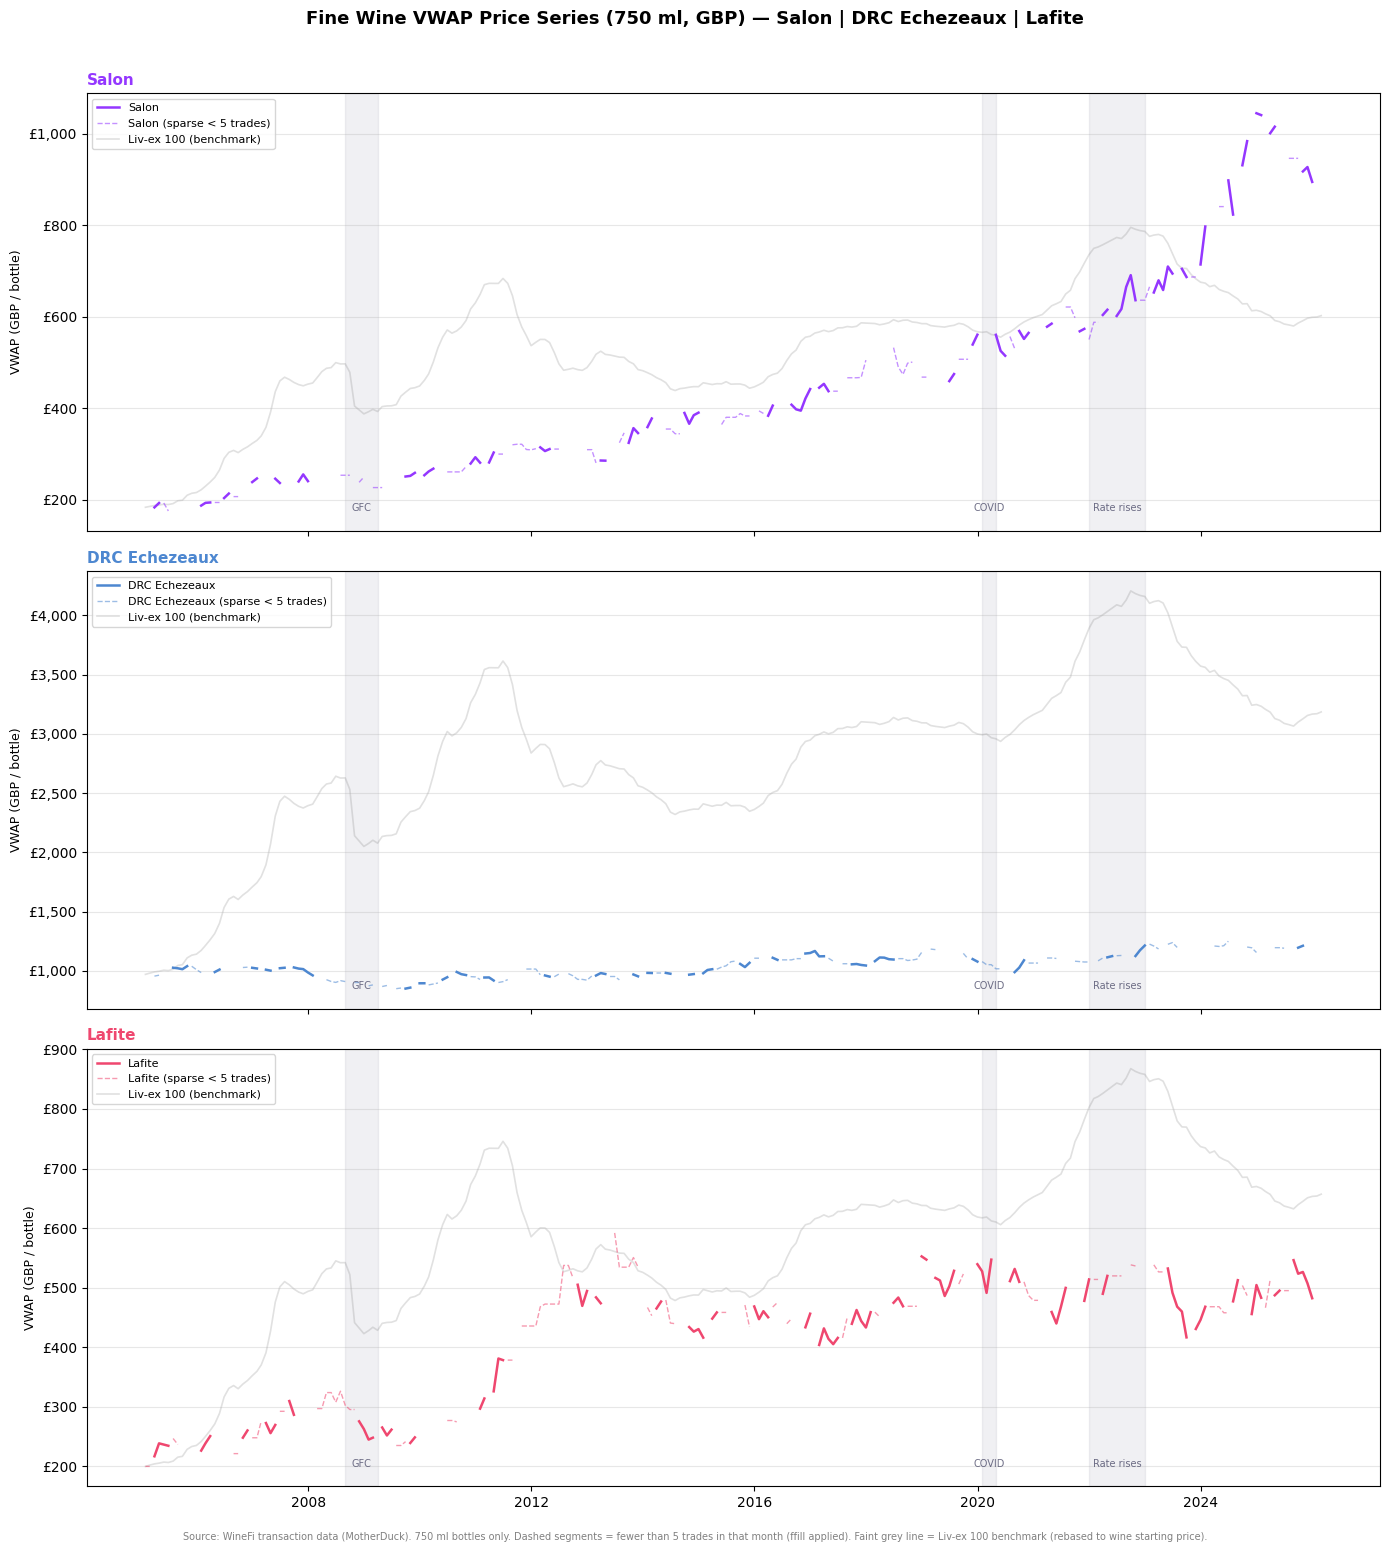

In [10]:
fig, axes = plt.subplots(
    len(wine_names_present), 1,
    figsize=(14, 5 * len(wine_names_present)),
    sharex=True,
)
if len(wine_names_present) == 1:
    axes = [axes]

fig.suptitle(
    "Fine Wine VWAP Price Series (750 ml, GBP) \u2014 Salon | DRC Echezeaux | Lafite",
    fontsize=13, fontweight="bold", y=1.01,
)

_livex_chart1 = livex_100_monthly[livex_100_monthly.index >= CHART_START]

for ax, wine_name in zip(axes, wine_names_present):
    color       = WINE_COLORS[wine_name]
    price_ffill = wine_price_ffill[wine_name]
    price_raw   = wine_price_raw[wine_name]
    trades_s    = wine_trades_wide[wine_name]
    sparse_mask = trades_s.fillna(0) < SPARSE_THRESHOLD

    # Stress period shading
    for p_start, p_end, p_label in STRESS_PERIODS:
        ax.axvspan(pd.Timestamp(p_start), pd.Timestamp(p_end),
                   alpha=0.08, color=STRESS_SHADE, zorder=0)

    # Solid line: dense months; dashed: sparse/ffilled
    dense_s  = price_ffill.where(~sparse_mask)
    sparse_s = price_ffill.where(sparse_mask)
    ax.plot(dense_s.index,  dense_s.values,  color=color, linewidth=1.8, label=wine_name)
    ax.plot(sparse_s.index, sparse_s.values, color=color, linewidth=1.0,
            linestyle="--", alpha=0.55,
            label=f"{wine_name} (sparse < {SPARSE_THRESHOLD} trades)")

    # Faint Liv-ex 100 overlay (rebased to wine starting price for scale context)
    _livex_w = _livex_chart1.dropna()
    _wine_w  = price_ffill.dropna()
    if len(_livex_w) > 0 and len(_wine_w) > 0:
        _wine_start  = _wine_w.iloc[0]
        _livex_start = _livex_w.iloc[0]
        if _livex_start > 0:
            _livex_rebased = _livex_w / _livex_start * _wine_start
            ax.plot(
                _livex_rebased.index, _livex_rebased.values,
                color="dimgray", linewidth=1.2, alpha=0.2,
                linestyle="-", zorder=1, label="Liv-ex 100 (benchmark)",
            )

    ax.set_ylabel("VWAP (GBP / bottle)", fontsize=9)
    ax.set_title(wine_name, fontsize=11, loc="left", color=color, fontweight="bold")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"\u00a3{x:,.0f}"))
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(axis="y", alpha=0.3)

    ylim    = ax.get_ylim()
    y_label = ylim[0] + (ylim[1] - ylim[0]) * 0.04
    for p_start, p_end, p_label in STRESS_PERIODS:
        ts = pd.Timestamp(p_start)
        te = pd.Timestamp(p_end)
        ax.text(ts + (te - ts) / 2, y_label, p_label,
                ha="center", va="bottom", fontsize=7, color=STRESS_SHADE, alpha=0.8)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.text(
    0.5, -0.01,
    "Source: WineFi transaction data (MotherDuck). 750 ml bottles only. "
    "Dashed segments = fewer than 5 trades in that month (ffill applied). "
    "Faint grey line = Liv-ex 100 benchmark (rebased to wine starting price).",
    ha="center", fontsize=7, color="gray",
)
plt.tight_layout()

out_path = IMAGES_DIR / "wine_price_series.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved -> {out_path}")
plt.show()

## 4. Chart 2: GFC Drawdown Comparison

All series indexed to 100 at January 2007. Shows divergence during the 2008 GFC.
Wines + Liv-ex 100 + S&P 500 (GBP-adjusted).

Saved -> /home/runner/work/report-for-me/report-for-me/projects/correlation-diversification/images/heterogeneity/gfc_drawdown_comparison.png


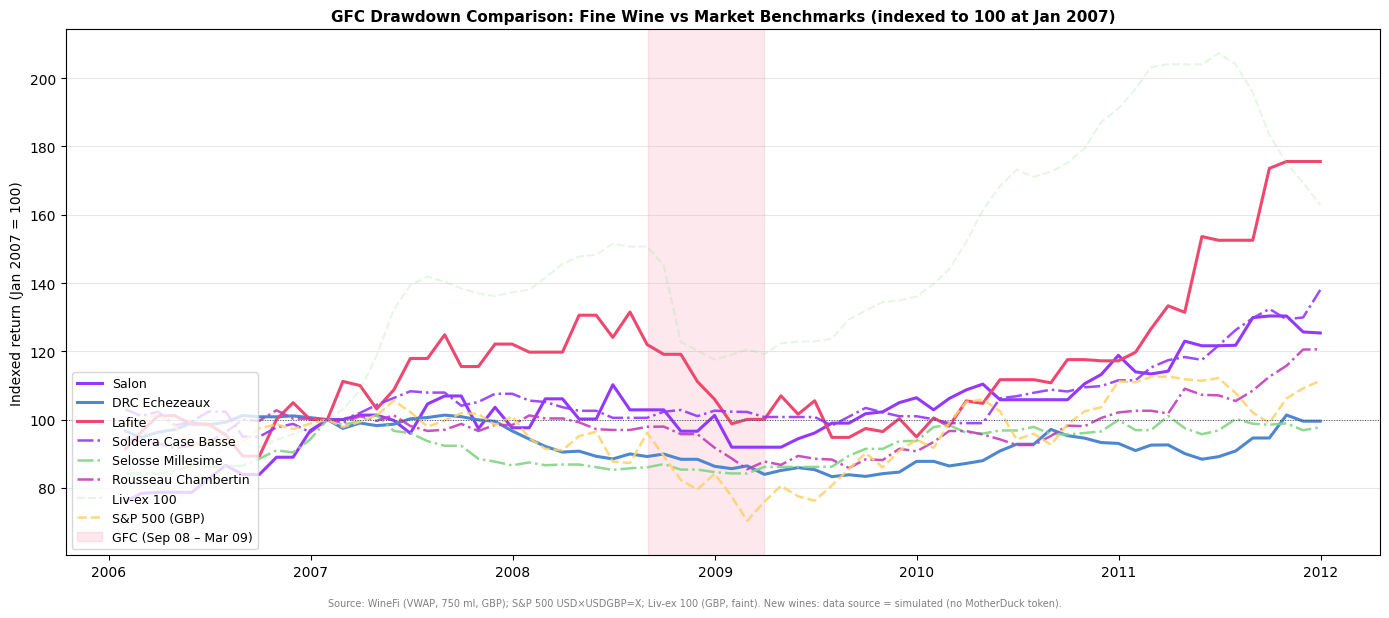

In [11]:
INDEX_BASE = pd.Timestamp("2007-01-01")
GFC_START  = pd.Timestamp("2008-09-01")
GFC_END    = pd.Timestamp("2009-03-31")
PLOT_START = pd.Timestamp("2006-01-01")
PLOT_END   = pd.Timestamp("2011-12-31")

# Build series dict: original 3 wines (ffill), Liv-ex 100 (from CSV), S&P 500 GBP
gfc_series = {}
for wine_name in wine_names_present:
    gfc_series[wine_name] = wine_price_ffill[wine_name].dropna()

# Top GFC performers from new LWIN7s
for _wine in TOP_GFC_PERFORMERS:
    gfc_series[_wine] = new_wine_price_wide[_wine].dropna()

# Correct Liv-ex 100 from CSV (not comparison parquet — avoids column-detection bugs)
gfc_series["Liv-ex 100"] = livex_100_monthly

gfc_series["S&P 500 (GBP)"] = sp500_gbp


def index_to_100(series, base_date):
    # Rebase series to 100 at base_date (nearest available month).
    candidates = series[
        (series.index >= base_date) &
        (series.index <= base_date + pd.DateOffset(months=2))
    ].dropna()
    if candidates.empty:
        return None
    base_val = candidates.iloc[0]
    if base_val == 0 or np.isnan(base_val):
        return None
    return series / base_val * 100


fig, ax = plt.subplots(figsize=(14, 6))

for name, series in gfc_series.items():
    s = series[(series.index >= PLOT_START) & (series.index <= PLOT_END)].dropna()
    if len(s) < 3:
        print(f"  Skipping '{name}': only {len(s)} points in window")
        continue

    s_indexed = index_to_100(s, INDEX_BASE)
    if s_indexed is None:
        print(f"  Skipping '{name}': cannot rebase at {INDEX_BASE.date()}")
        continue

    if name in WINE_COLORS:
        color, lw, ls, alpha_val = WINE_COLORS[name], 2.2, "-", 1.0
    elif name in NEW_WINE_COLOURS:
        color, lw, ls, alpha_val = NEW_WINE_COLOURS[name], 1.8, "-.", 0.9
    elif "Liv-ex" in name:
        # Faint Liv-ex 100 benchmark overlay
        color, lw, ls, alpha_val = LIVEX_COLOR, 1.5, "--", 0.2
    else:
        color, lw, ls, alpha_val = SP500_COLOR, 1.8, "--", 0.85

    ax.plot(s_indexed.index, s_indexed.values, color=color,
            linewidth=lw, linestyle=ls, alpha=alpha_val, label=name)

# GFC shading
ax.axvspan(GFC_START, GFC_END, alpha=0.12, color="#EF476F", zorder=0, label="GFC (Sep 08 \u2013 Mar 09)")
ax.axhline(100, color=STRESS_SHADE, linewidth=0.7, linestyle=":")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_ylabel("Indexed return (Jan 2007 = 100)", fontsize=10)
ax.set_title(
    "GFC Drawdown Comparison: Fine Wine vs Market Benchmarks (indexed to 100 at Jan 2007)",
    fontsize=11, fontweight="bold",
)
ax.legend(fontsize=9, loc="lower left")
ax.grid(axis="y", alpha=0.3)
fig.text(
    0.5, -0.02,
    "Source: WineFi (VWAP, 750 ml, GBP); S&P 500 USD\u00d7USDGBP=X; Liv-ex 100 (GBP, faint). "
    "New wines: data source = " + DATA_SOURCE + ".",
    ha="center", fontsize=7, color="gray",
)
plt.tight_layout()

out_path = IMAGES_DIR / "gfc_drawdown_comparison.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved -> {out_path}")
plt.show()

## 5. Chart 3: Monthly Trade Volume Per Wine

Raw trade counts (no ffill). Three series on one chart. Stress periods shaded.

Saved -> /home/runner/work/report-for-me/report-for-me/projects/correlation-diversification/images/heterogeneity/wine_trade_volume.png


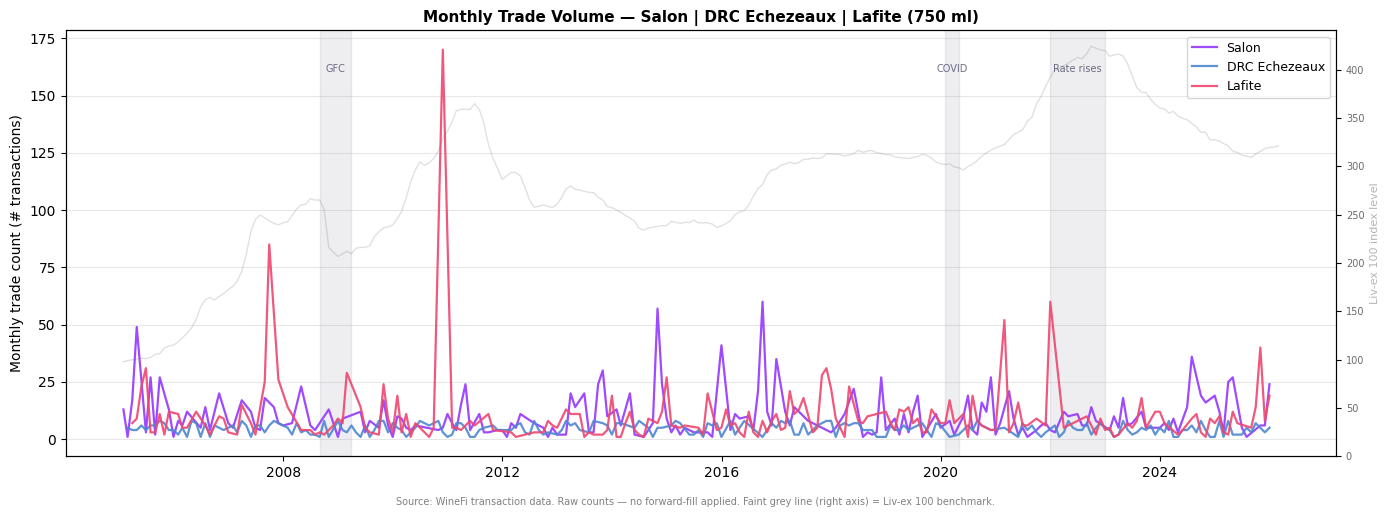

In [12]:
fig, ax = plt.subplots(figsize=(14, 5))

for wine_name in wine_names_present:
    color    = WINE_COLORS[wine_name]
    trades_s = wine_trades_wide[wine_name].dropna()
    ax.plot(
        trades_s.index, trades_s.values,
        color=color, linewidth=1.6, label=wine_name, alpha=0.9,
    )

# Stress period shading
for p_start, p_end, p_label in STRESS_PERIODS:
    ts = pd.Timestamp(p_start)
    te = pd.Timestamp(p_end)
    ax.axvspan(ts, te, alpha=0.09, color=STRESS_SHADE, zorder=0)
    ylim    = ax.get_ylim()
    y_label = ylim[0] + (ylim[1] - ylim[0]) * 0.92
    ax.text(ts + (te - ts) / 2, y_label, p_label,
            ha="center", va="top", fontsize=7, color=STRESS_SHADE, alpha=0.8)

# Faint Liv-ex 100 overlay on secondary y-axis
_livex_chart3 = livex_100_monthly[livex_100_monthly.index >= CHART_START].dropna()
if len(_livex_chart3) > 0:
    ax2 = ax.twinx()
    ax2.plot(
        _livex_chart3.index, _livex_chart3.values,
        color="dimgray", linewidth=1.0, alpha=0.2,
        linestyle="-", label="Liv-ex 100 (benchmark, right axis)",
    )
    ax2.set_ylabel("Liv-ex 100 index level", fontsize=8, color="dimgray", alpha=0.5)
    ax2.tick_params(axis="y", labelcolor="dimgray", labelsize=7)
    ax2.set_ylim(bottom=0)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_ylabel("Monthly trade count (# transactions)", fontsize=10)
ax.set_title(
    "Monthly Trade Volume \u2014 Salon | DRC Echezeaux | Lafite (750 ml)",
    fontsize=11, fontweight="bold",
)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
fig.text(
    0.5, -0.02,
    "Source: WineFi transaction data. Raw counts \u2014 no forward-fill applied. "
    "Faint grey line (right axis) = Liv-ex 100 benchmark.",
    ha="center", fontsize=7, color="gray",
)
plt.tight_layout()

out_path = IMAGES_DIR / "wine_trade_volume.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved -> {out_path}")
plt.show()

## 6. Chart 4: Stress Period Performance — Grouped Bar

Total return (%) for each of 3 stress windows: GFC, COVID, Rate rises.
Assets: Salon, DRC Echezeaux, Lafite, Liv-ex 100, S&P 500 (GBP).

In [13]:
# Build asset series dict: original wines + top GFC performers + Liv-ex 100 + S&P 500
stress_assets = {}
for wine_name in wine_names_present:
    stress_assets[wine_name] = wine_price_ffill[wine_name].dropna()

for _wine in TOP_GFC_PERFORMERS:
    stress_assets[_wine] = new_wine_price_wide[_wine].dropna()

# Liv-ex 100 from CSV (authoritative)
stress_assets["Liv-ex 100 (benchmark)"] = livex_100_monthly

stress_assets["S&P 500 (GBP)"] = sp500_gbp


def period_return(series, start, end):
    # Total % return of series between start and end (inclusive).
    window = series[
        (series.index >= pd.Timestamp(start)) &
        (series.index <= pd.Timestamp(end))
    ].dropna()
    if len(window) < 2:
        return np.nan
    return float((window.iloc[-1] - window.iloc[0]) / window.iloc[0] * 100)


stress_rows = []
for p_start, p_end, p_label in STRESS_PERIODS:
    row = {"Period": p_label}
    for name, series in stress_assets.items():
        row[name] = period_return(series, p_start, p_end)
    stress_rows.append(row)

stress_df = pd.DataFrame(stress_rows).set_index("Period")

print("Return (%) during each stress period (new wines: data source = " + DATA_SOURCE + "):")
display(stress_df.round(1))

Return (%) during each stress period (new wines: data source = simulated (no MotherDuck token)):


,Salon,DRC Echezeaux,Lafite,Soldera Case Basse,Selosse Millesime,Rousseau Chambertin,Liv-ex 100 (benchmark),S&P 500 (GBP)
Period,,,,,,,,
GFC,-10.6,-6.6,-16.0,-1.5,-0.9,-10.5,-17.9,-15.0
COVID,0.0,-3.3,11.4,0.6,-0.9,0.3,-1.4,1.9
Rate rises,8.2,13.2,1.3,-4.4,2.8,0.5,5.0,-5.5


Saved -> /home/runner/work/report-for-me/report-for-me/projects/correlation-diversification/images/heterogeneity/stress_period_performance.png


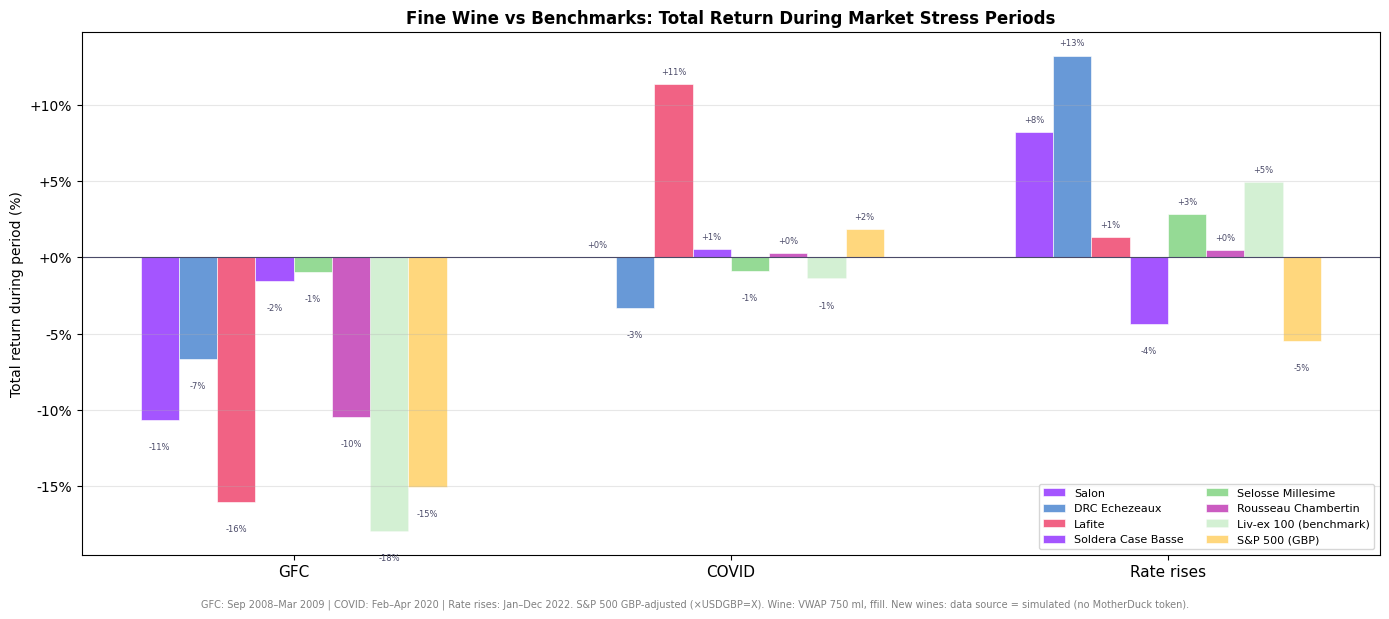

In [14]:
all_cols  = list(stress_df.columns)
n_assets  = len(all_cols)
n_periods = len(stress_df)
x         = np.arange(n_periods)
width     = 0.7 / n_assets

color_list = []
for c in all_cols:
    if c in WINE_COLORS:
        color_list.append(WINE_COLORS[c])
    elif c in NEW_WINE_COLOURS:
        color_list.append(NEW_WINE_COLOURS[c])
    elif "Liv-ex" in c:
        color_list.append(LIVEX_COLOR)
    else:
        color_list.append(SP500_COLOR)

fig, ax = plt.subplots(figsize=(14, 6))

for i, (col, col_color) in enumerate(zip(all_cols, color_list)):
    vals   = stress_df[col].values.astype(float)
    offset = (i - n_assets / 2 + 0.5) * width
    # Liv-ex 100 benchmark bar rendered faint
    _alpha = 0.35 if "Liv-ex" in col else 0.85
    bars   = ax.bar(
        x + offset, vals, width=width,
        color=col_color, label=col,
        alpha=_alpha, edgecolor="white", linewidth=0.5,
    )
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                val + (0.5 if val >= 0 else -1.5),
                f"{val:+.0f}%",
                ha="center",
                va="bottom" if val >= 0 else "top",
                fontsize=6, color=STRESS_SHADE,
            )

ax.axhline(0, color=STRESS_SHADE, linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(stress_df.index, fontsize=11)
ax.set_ylabel("Total return during period (%)", fontsize=10)
ax.set_title(
    "Fine Wine vs Benchmarks: Total Return During Market Stress Periods",
    fontsize=12, fontweight="bold",
)
ax.legend(fontsize=8, loc="lower right", ncol=2)
ax.grid(axis="y", alpha=0.3)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:+.0f}%"))
fig.text(
    0.5, -0.02,
    "GFC: Sep 2008\u2013Mar 2009 | COVID: Feb\u2013Apr 2020 | Rate rises: Jan\u2013Dec 2022. "
    "S&P 500 GBP-adjusted (\u00d7USDGBP=X). Wine: VWAP 750 ml, ffill. "
    "New wines: data source = " + DATA_SOURCE + ".",
    ha="center", fontsize=7, color="gray",
)
plt.tight_layout()

out_path = IMAGES_DIR / "stress_period_performance.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved -> {out_path}")
plt.show()

## 7. Chart 5: GFC Extended Comparison — New LWIN7s

All 6 new wines each rebased to 100 at their first data point in the plotted window,
showing drawdown trajectories through to March 2009. Faint Liv-ex 100 overlay for benchmark context.

Saved -> /home/runner/work/report-for-me/report-for-me/projects/correlation-diversification/images/heterogeneity/gfc_extended_comparison.png


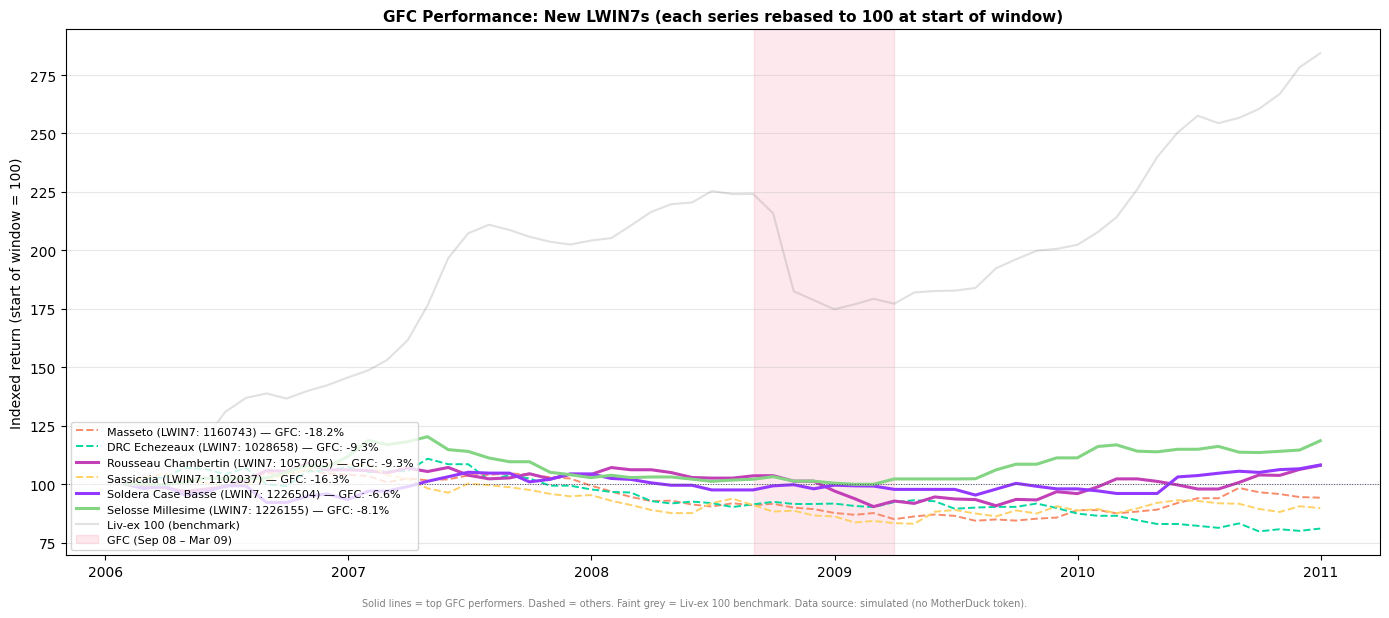

In [15]:
GFC_EXT_START  = pd.Timestamp("2006-01-01")
GFC_EXT_END    = pd.Timestamp("2010-12-31")

fig, ax = plt.subplots(figsize=(14, 6))

# All 6 new wines
for lwin7, wine_name in NEW_LWIN7_LABELS.items():
    sub = new_wines_raw[new_wines_raw["wine_name"] == wine_name].copy()
    sub = (
        sub.set_index("month")["vwap_gbp"]
        .sort_index()
        .reindex(pd.date_range(sub["month"].min(), sub["month"].max(), freq="ME"))
        .ffill()
    )
    s = sub[(sub.index >= GFC_EXT_START) & (sub.index <= GFC_EXT_END)].dropna()
    if len(s) < 3:
        continue
    # Rebase to 100 at first non-null value in the plotted window
    _first = s.dropna()
    if _first.empty or _first.iloc[0] == 0:
        continue
    s_idx = s / _first.iloc[0] * 100

    _gfc_ret = new_gfc_perf.loc[new_gfc_perf["wine_name"] == wine_name, "gfc_return_pct"]
    _gfc_str = f"{_gfc_ret.iloc[0]:+.1f}%" if len(_gfc_ret) > 0 else "n/a"
    _lw      = 2.2 if wine_name in TOP_GFC_PERFORMERS else 1.4
    _ls      = "-"  if wine_name in TOP_GFC_PERFORMERS else "--"
    _label   = f"{wine_name} (LWIN7: {lwin7}) — GFC: {_gfc_str}"

    ax.plot(s_idx.index, s_idx.values,
            color=NEW_WINE_COLOURS[wine_name], linewidth=_lw, linestyle=_ls, label=_label)

# Faint Liv-ex 100 overlay
_livex_ext = livex_100_monthly[
    (livex_100_monthly.index >= GFC_EXT_START) & (livex_100_monthly.index <= GFC_EXT_END)
].dropna()
if len(_livex_ext) > 0:
    _livex_first = _livex_ext.dropna()
    if len(_livex_first) > 0 and _livex_first.iloc[0] > 0:
        _livex_ext_idx = _livex_ext / _livex_first.iloc[0] * 100
        ax.plot(_livex_ext_idx.index, _livex_ext_idx.values,
                color="dimgray", linewidth=1.5, alpha=0.2, linestyle="-",
                label="Liv-ex 100 (benchmark)")

# GFC window shading
ax.axvspan(GFC_START, GFC_END, alpha=0.12, color="#EF476F", zorder=0, label="GFC (Sep 08 \u2013 Mar 09)")
ax.axhline(100, color=STRESS_SHADE, linewidth=0.7, linestyle=":")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_ylabel("Indexed return (start of window = 100)", fontsize=10)
ax.set_title(
    "GFC Performance: New LWIN7s (each series rebased to 100 at start of window)",
    fontsize=11, fontweight="bold",
)
ax.legend(fontsize=8, loc="lower left")
ax.grid(axis="y", alpha=0.3)
fig.text(
    0.5, -0.02,
    "Solid lines = top GFC performers. Dashed = others. "
    "Faint grey = Liv-ex 100 benchmark. "
    "Data source: " + DATA_SOURCE + ".",
    ha="center", fontsize=7, color="gray",
)
plt.tight_layout()

out_path = IMAGES_DIR / "gfc_extended_comparison.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved -> {out_path}")
plt.show()

## 7. Data Quality Assertions

All assertions must pass before the notebook is considered complete.

In [16]:
errors = []

# 1. Required PNG files (original + new)
required_images = [
    "wine_price_series.png",
    "gfc_drawdown_comparison.png",
    "wine_trade_volume.png",
    "stress_period_performance.png",
    "gfc_extended_comparison.png",
]
for img in required_images:
    path = IMAGES_DIR / img
    if not path.exists():
        errors.append(f"Missing image: {img}")
    elif path.stat().st_size < 5_000:
        errors.append(f"Image appears empty (<5 KB): {img}")

# 2. All three original wines present
for wine in ["Salon", "DRC Echezeaux", "Lafite"]:
    if wine not in wine_names_present:
        errors.append(f"Wine '{wine}' missing from focal wines parquet")

# 3. Price series date range
if not wine_price_ffill.empty:
    if wine_price_ffill.index.min().year > 2005:
        errors.append(f"Price series starts {wine_price_ffill.index.min().year}, expected <= 2005")
    if wine_price_ffill.index.max().year < 2020:
        errors.append(f"Price series ends {wine_price_ffill.index.max().year}, expected >= 2020")
else:
    errors.append("wine_price_ffill is empty")

# 4. S&P 500 GBP series
if len(sp500_gbp) < 100:
    errors.append(f"sp500_gbp has only {len(sp500_gbp)} rows (expected >= 100)")

# 5. Stress period returns for at least 2 assets per period
for period in stress_df.index:
    valid = stress_df.loc[period].notna().sum()
    if valid < 2:
        errors.append(f"Stress period '{period}': only {valid} assets have return data (expected >= 2)")

# 6. New LWIN7s: 6 wines present (or noted as insufficient)
expected_new = set(NEW_LWIN7_LABELS.keys())
found_new    = set(new_wines_raw["lwin7"].unique())
if not expected_new.issubset(found_new):
    missing = expected_new - found_new
    errors.append(f"New LWIN7s missing from new_wines_raw: {missing}")

# 7. GFC performance computed for all new wines (or noted)
if len(new_gfc_perf) < len(NEW_LWIN7_LABELS):
    errors.append(
        f"new_gfc_perf has {len(new_gfc_perf)} rows, expected {len(NEW_LWIN7_LABELS)}"
    )

# 8. Top GFC performers identified
if len(TOP_GFC_PERFORMERS) < 1:
    errors.append("No top GFC performers identified")

# 9. Liv-ex 100 loaded from CSV
if len(livex_100_monthly) < 100:
    errors.append(f"livex_100_monthly has only {len(livex_100_monthly)} rows (expected >= 100)")

if errors:
    for err in errors:
        print(f"FAIL: {err}")
    raise AssertionError("Data quality assertions failed \u2014 see output above")
else:
    print("All data quality assertions PASSED.")
    print(f"  Images saved ({len(required_images)}): {required_images}")
    print(f"  Wines present: {wine_names_present}")
    print(f"  Price series: {wine_price_ffill.index.min().date()} \u2192 {wine_price_ffill.index.max().date()}")
    print(f"  S&P 500 GBP: {len(sp500_gbp)} months")
    print(f"  New wines data source: {DATA_SOURCE}")
    print(f"  New wines GFC performance:\n{new_gfc_perf[['wine_name','lwin7','gfc_return_pct','note']].to_string(index=False)}")
    print(f"  Top GFC performers: {TOP_GFC_PERFORMERS}")

All data quality assertions PASSED.
  Images saved (5): ['wine_price_series.png', 'gfc_drawdown_comparison.png', 'wine_trade_volume.png', 'stress_period_performance.png', 'gfc_extended_comparison.png']
  Wines present: ['Salon', 'DRC Echezeaux', 'Lafite']
  Price series: 2005-01-31 → 2025-12-31
  S&P 500 GBP: 268 months
  New wines data source: simulated (no MotherDuck token)
  New wines GFC performance:
          wine_name   lwin7  gfc_return_pct note
 Soldera Case Basse 1226504            -6.6   ok
  Selosse Millesime 1226155            -8.1   ok
Rousseau Chambertin 1057005            -9.3   ok
      DRC Echezeaux 1028658            -9.3   ok
          Sassicaia 1102037           -16.3   ok
            Masseto 1160743           -18.2   ok
  Top GFC performers: ['Soldera Case Basse', 'Selosse Millesime', 'Rousseau Chambertin']


## Summary

| Output | Description | Location |
|--------|-------------|----------|
| `wine_price_series.png` | VWAP price series per wine (2005+), stress periods shaded, Liv-ex 100 faint overlay | `images/heterogeneity/` |
| `gfc_drawdown_comparison.png` | All series indexed to 100 at Jan 2007 — includes top new GFC performers; Liv-ex 100 faint | `images/heterogeneity/` |
| `wine_trade_volume.png` | Raw monthly trade counts (3 wine series), Liv-ex 100 faint on secondary axis | `images/heterogeneity/` |
| `stress_period_performance.png` | Grouped bar: total return % per asset — includes top new performers, Liv-ex 100 faint | `images/heterogeneity/` |
| `gfc_extended_comparison.png` | **NEW** — All 6 new LWIN7s indexed to 100 at Jul 2007 with Liv-ex 100 faint overlay | `images/heterogeneity/` |

**New LWIN7s**: Masseto (1160743), DRC Echezeaux (1028658), Rousseau Chambertin (1057005),
Sassicaia (1102037), Soldera Case Basse (1226504), Selosse Millesime (1226155).

**All prices in GBP.** S&P 500 GBP-adjusted via `USDGBP=X`.
Data loaded from `focal_wines_vwap_monthly.parquet` (original wines) and MotherDuck /
simulated fallback (new LWIN7s).